<a href="https://colab.research.google.com/github/rachakondasaivarshini/GAN-PROGRAMS/blob/main/Gan_exp3_prelab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, filters, feature, util
from skimage.filters import gaussian
from skimage.morphology import disk
from skimage.filters.rank import median

In [5]:
image = data.camera()

noisy_image = util.random_noise(
    image,
    mode="s&p",
    amount=0.03
)

noisy_uint8 = util.img_as_ubyte(noisy_image)

In [6]:
gaussian_filters = gaussian(
    noisy_image,
    sigma=1.5
)

In [7]:
median_filters = median(
    noisy_uint8,
    footprint=disk(2)
)

In [12]:
gaussian_filtered = gaussian(noisy_image, sigma=1)

sobel_edges = filters.sobel(gaussian_filtered)

In [14]:
predict_edges = feature.canny(gaussian_filtered)

In [16]:
canny_edges = feature.canny(
    gaussian_filtered,
    sigma=1.5,
    low_threshold=0.1,
    high_threshold=0.2
)

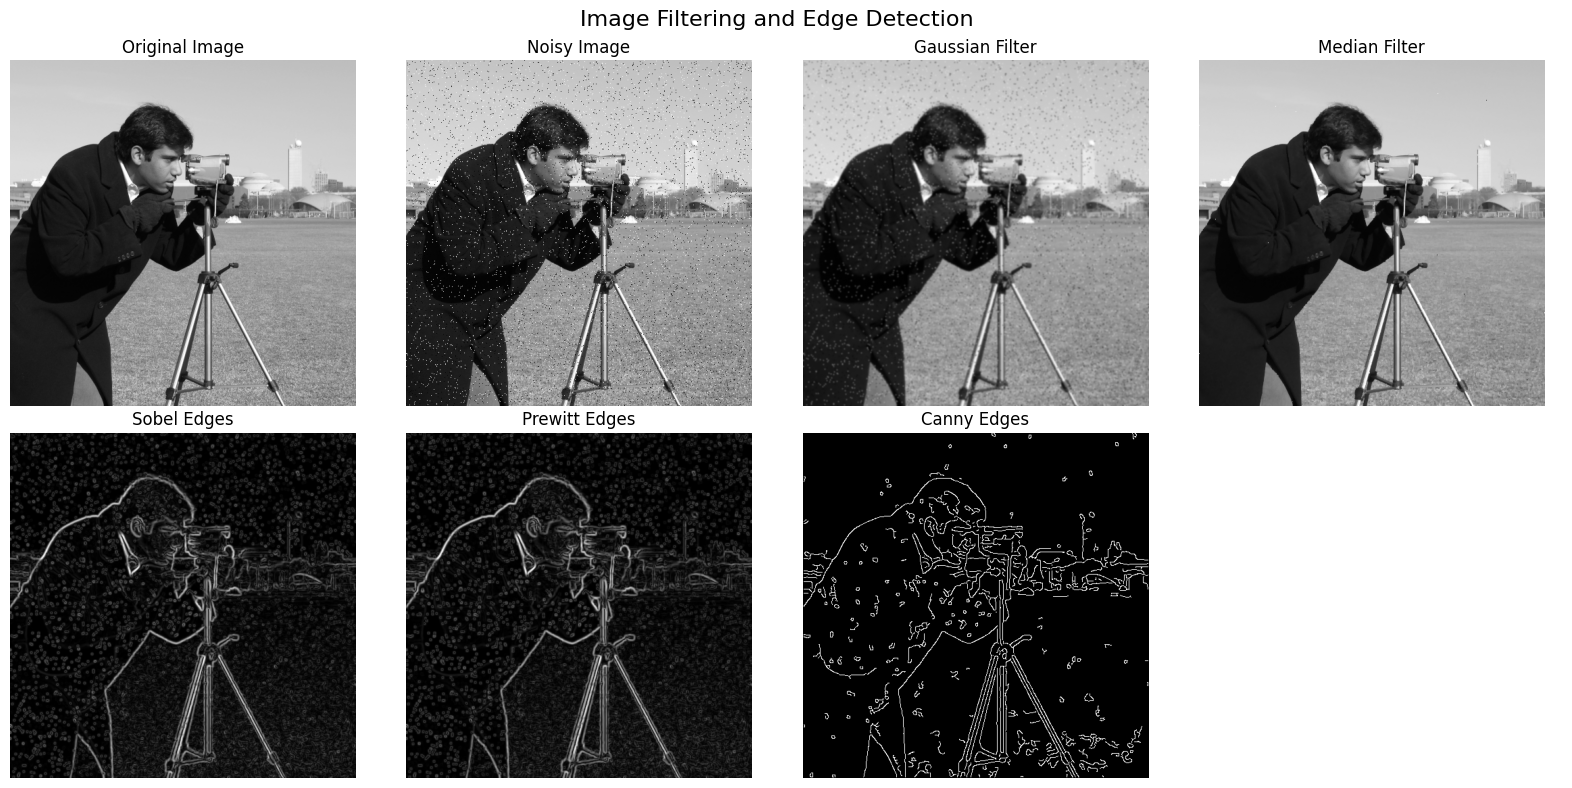

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, feature
from skimage.filters import gaussian
from skimage.morphology import disk
from skimage.filters.rank import median

# 1. Load image
image = data.camera()

# 2. Add salt-and-pepper noise
noisy_image = util.random_noise(image, mode="s&p", amount=0.03)

# 3. Gaussian filter
gaussian_filtered = gaussian(noisy_image, sigma=1)

# 4. Median filter
noisy_uint8 = util.img_as_ubyte(noisy_image)
median_filtered = median(noisy_uint8, footprint=disk(1))

# 5. Sobel edge detection
sobel_edges = filters.sobel(gaussian_filtered)

# 6. Prewitt edge detection
prewitt_edges = filters.prewitt(gaussian_filtered)

# 7. Canny edge detection
canny_edges = feature.canny(
    gaussian_filtered,
    sigma=1.5,
    low_threshold=0.1,
    high_threshold=0.2
)

# 8. Organize images and titles
images = [
    image,
    noisy_image,
    gaussian_filtered,
    median_filtered,
    sobel_edges,
    prewitt_edges,
    canny_edges
]

titles = [
    "Original Image",
    "Noisy Image",
    "Gaussian Filter",
    "Median Filter",
    "Sobel Edges",
    "Prewitt Edges",
    "Canny Edges"
]

# 9. Display
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for axis, img, title in zip(axes.ravel(), images, titles):
    axis.imshow(img, cmap="gray")
    axis.set_title(title)
    axis.axis("off")

axes[1, 3].axis("off")

plt.suptitle("Image Filtering and Edge Detection", fontsize=16)
plt.tight_layout()
plt.show()